## Session 2 — Modeling Randomness & Input Analysis

**Course:** Decision Modelling — Simulation Part
**Session:** 2 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Fit probability distributions to real, empirical data
- Generate random variates from a fitted distribution
- Test whether a distributional assumption is statistically reasonable (goodness-of-fit)
- Justify an input-modeling choice — not just produce one
- Draw samples from the fitted distribution.

## Where this session fits

- **Looking back:** Session 1 introduced randomness informally (a fair die, a fixed-probability arrival process). Today we stop assuming we know the "true" distribution and instead learn how to infer it from data.
- **Looking ahead:** every Monte Carlo model (Sessions 3–4) and every SimPy model (Sessions 6–12) needs random inputs — interarrival times, service times, demand, machine faluire, etc. The techniques from today are exactly how you'll justify those inputs rather than picking them arbitrarily.
- **Cross-course link:** Advanced Data Analysis covers forecasting — a demand forecast is itself often the starting point for an input distribution here (e.g. a forecast plus its historical error distribution can become a demand *distribution*, not just a point estimate).


## Further reading 

- Chapter 9 from *Banks, J. (2005). Discrete event system simulation (4th ed.). Pearson Education India*.
- Chapter X from *Kelton W.d., Zupick N., and Ivey N. (2023). Simulation with Arena (7th ed.), McGraw Hill*.


## 1. Why input modeling matters

Input models provide the driving force for a simulation model. In the simulation of a queueing system,
typical input models are the distributions of time between arrivals and of service times. For an inventorysystem
simulation, input models include the distributions of demand and of lead time. For the simulation of
a reliability system, the distribution of time to failure of a component is an example of an input model.
A simulation model is only as trustworthy as the random inputs that drive it. If we simulate arrivals as "uniformly random" when in reality they cluster around lunchtime, or model service times as constant when they're highly variable, our conclusions about queues, costs, and service levels will be wrong, no matter how carefully we code the rest of the model.

Modelling has two aspects:
- **Logical aspect**: What are the entities? How they enter and leave the model? What paths they follow? Which resources they need? Etc. This is what we call *structural* modelling.
- **Numerical aspect**: How arrivals, processing times, failures, etc. can be described using numerical values and probability distributions? This is what we call *quantitative* modelling.

Input modeling is where reality enters the simulation. This is exactly why we treat it as a first-class topic rather than an afterthought: the decision-modeling value of a simulation study rests on the credibility of its inputs, not just the sophistication of its logic. Regardless of the sophistication of the analyst, fualty models of the inputs will lead to outputs whose interpretation could give rise to misleading recommendations (Garbage In, Garbage Out). 

Input can be either 
- **Deterministic**: nonrandom, fixed values, point estimate of the deterministic input would be sufficient for modelling.

  Or 
- **Random** (a.k.a. stochastic): We model it as a distribution, then “draw” or “generate” values from that distribution to drive simulation. Here, there are further questions to be answered:
    - What distribution?  
    - What parameters?

We don't just assume randomness away as we should always pay attention to model validity. We will discuss model validation and verification in Session 12. In this session, we are interested in the second type of input, i.e., random inputs. Randomness in input causes simulation output to be random, too (Random In, Random Out). We will learn about analyzing random outputs in Sessions 7-9.


## 2. Input modeling workflow

There are four steps in the development of a useful model of input data:
- Step 1: Collecting data from the system of interest. This involves real measurements from the system (or the closest available proxy).
- Step 2: Identifying  a probability distribution to represent the input process. This can be done through visualization to get a feel for shape, skew, and range.
- Step 3: Hypothesize candidate distribution(s), informed by the shape *and* by domain knowledge.
- Step 4: Estimating parameters that determine a specific instance of the distribution family. This is typically done via Maximum Likelihood Estimation (MLE).
- Step 5: Evaluating the chosen distribution and the associated parameters for goodness of fit. This steps answers the question about whether the data plausibly come from the fitted distribution? (e.g. Kolmogorov–Smirnov, chi-square tests.). If more than one distribution seemed plausible, compare fits
- Step 6: Selecting and justifying. This is done by documenting *why* this distribution and these parameters were chosen.


---
### Data collection 

#### Where data comes from? 
Data comes from:
- System specifications, databases, interviews
- Observing the real world

This requires data collection, a task that can be time-consuming, expensive, and frustrating. The task becomes cumbersome when relevant data is *dirty*, available data is for wrong things, or even data is not available. We might also be interested in making a model of a non-existing system. What should we do then?

#### Suggestions for data collection
Below, you find a list of suggestions for data collection that can enhance and facilitate the task, although they are not all ionclusive:

1. <u>A useful expenditure of time is in planning</u>. This could begin by a practice or preobserving session.
Try to collect data while preobserving. Devise forms for this purpose. It is very likely that these
forms will have to be modified several times before the actual data collection begins. Watch for
unusnal circumstances, and consider how they will be handled. Planning is important, even if data will be collected
automatically (e.g., via computer data collection), to ensure that the appropriate data are available.
When data have already been collected by someone else, be sure to allow plenty of time for converting
the data into a usable format.
2. <u>Try to analyze the data as they are being collected</u>. Figure out whether the data being collected are
adequate to provide the distributions needed as input to the simulation. Find out whether any data
being collecled are useless to the simulation. There is no need to collect superfluous data.
3. <u>Identify what input parameters require more precise definition</u>. Build a preliminary version of the simulation model, and perform sensitivity analysis to identify what parameters have important influence on key output performance measures.

4. <u>Try to combine homogeneous data sets</u>. Check data for homogeneity in successive time periods
and during the same time period on successive days. For example, check for homogeneity of data
from 2:00 P.M. to 3:00 P.M. and 3:00 P.M. to 4:00 P.M., and check to see whether the data are holnogeneons
for 2:00 P.M. to 3:00P.M. on Thursday and Friday. When checking for homogeneity, an initial
test is to see whether the means of the distributions (the average interarrival times, for example) are
the same. The two-sample t test can be used for this purpose. A more thorough analysis would
require a test of the equivalence of the distributions, perhaps via a quantile-quantile plot (described
later).
5. <u>Be aware of the possibility of data censoring, in which a quantity of interest is not observed in its
entirety</u>. This problem most often occurs when the analyst is interested in the time required to complete some process (for example, produce a part, treat a patient, or have a component fa il), but
the process begins prior to, or finishes after the completion of, the observation period. Censoring can
result in especially long process times being left out of the data sample.
6. <u>To discover whether there is a relationship between two variables, build a scatter diagram</u>.
Sometimes an eyeball scan of the scatter diagram will indicate whether there is a relationship
between two variables of interest. Section 9.7 describes models fo r statistically dependent input
data.
7. <u>Consider the possibility that a sequence of observations that appear to be independent actually has
autocorrelation</u>. Autocorrelation can exist in successive time periods or for successive customers.


#### What if data is not available?
It happens more often than you’d like that you cannot find the data needed for modelling a system. There is also cases in which we might need to make a preliminary model (to perform some pretests or for demonstration purposes) beore data is collected or even available. There is not good solution to solve this issue. But here are some (bad) options that one can go for:
- Engineering data: Often a product or process has performance ratings provided by the manufacturer (for example, the mean time to failure of a disk drive is 10000 hours; a laser printer can produce 8.pages/minute; the cutting speed of a tool is 1 cm/second; etc.). Company rules might specify time or productJon standards. These values provide a starting point for input modeling by fixing a central value.
- Expert opinion: Talk to the people who are experienced with the process or similar processes. Often, they can provide optimistic, pessimistic, and most-likely values. They might also be able to say whether the process is nearly constant highly variable, and they might be able to define the source of variability.
- Physical or conventional limitations: Most real processes have physical limits on performance. For example, computer data entry cannot be faster than a person can type. Because of company policies, there could be upper limits on how long a process may take. Do not ignore obvious limits or bounds that narrow the range of the input process.
- The nature of the process: The description of the distributions in Section XX can be used to justify a particular choice even when no data are available.


Moreover, if you have a minimum and a maximum value for the variable or its average value together with a % error or absolute error you might assume a uniform distribution. Likeiwse, if you have an optimizatic, a pessimistic, and a most likely value for the variable, then you might assume a triangular distribution. If a beta distribution is used, then be sure to plot the density function of the selected distribution; the beta can take unusual shapes.

Note that these are some probably bad options! 



---
### Histogram

In this section, we discuss methods for selecting families of input distributions when data are available. The specific distribution within a family is specified by estimating its parameters in the nest section.

A frequency distribution or histogram is useful in identifying the shape of a distribution. A histogram is
constructed as follows:

1. Divide the range of the data into intervals. (Intervals are usually of equal width; however, unequal widths may be used if the heights of the frequencies are adjusted.)
2. Label the horizontal axis to conform to the intervals selected.
3. Find the frequency of occurrences within each interval.
4. Label the vertical axis so that the total occurrences can be plotted for each interval.
5. Plot the frequencies on the vertical axis.
   
**Example:** The manager of a busy downtown cafe, *The Daily Grind*, noticed a bottleneck building at the register during morning peak hours. To model the service system and run a discrete-event simulation, the team recorded the precise order time (in minutes), from the moment a customer steps up to the counter, asks questions, and pays, to when the barista hands them their receipt, for $n = 1,000$ consecutive customers. The data set is given in `inputanalyzer_ordertimes.txt` file. Make a histogram for the dataset. 


n = 1000
mean = 12.00, std = 1.64
min = 6.87, max = 17.51
Number of bins = 20.


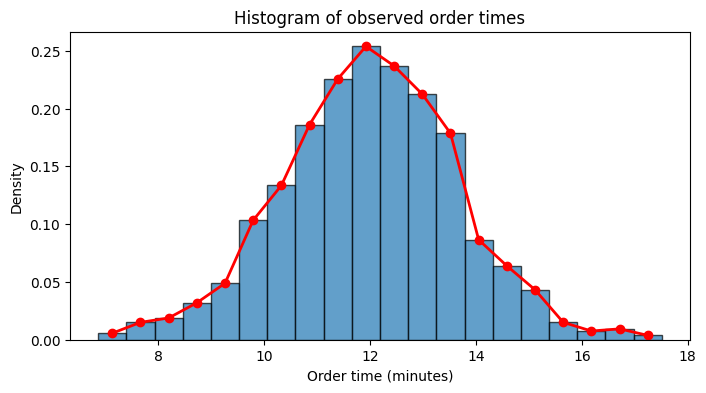

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

order_times = np.loadtxt('data/session02_order_times.txt')

# Here we determine the number of bins.
#
# Order times are continuous measurements ($6.87 \text{ mins}, 12.04 \text{ mins}$, etc.) 
# that can take any real value on a continuous spectrum. When passing bins=30, matplotlib 
# divides the range between min ($6.87$) and max ($17.51$) into 30 equally sized continuous 
# intervals. Because individual datapoints are decimal values, precise integer centering is
# neither needed nor meaningful.

number_of_bins = 20

print(f"n = {len(order_times)}")
print(f"mean = {order_times.mean():.2f}, std = {order_times.std():.2f}")
print(f"min = {order_times.min():.2f}, max = {order_times.max():.2f}")
print("==========================")
print(f"Number of bins = {number_of_bins:.0f}.")

counts, bin_edges = np.histogram(order_times, bins=number_of_bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 4))
plt.hist(order_times, bins=number_of_bins, density=True, edgecolor='black', alpha=0.7)
plt.plot(bin_centers, counts, color='red', marker='o', linestyle='-', linewidth=2, label='Frequency Polygon')
plt.xlabel('Order time (minutes)')
plt.ylabel('Density')
plt.title('Histogram of observed order times')
plt.show()



The number of class intervals (or bins) depends on the number of observations and on the amount of scatter or dispersion in the data. Choosing the number of class intervals approximately equal to the square root of the sample size often works well in practice. 
Regarding the size of class intervals (the number of bins):

- If the intervals are too wide (the number of bins is small), the histogram will be coarse, or blocky, and its shape and other details will not show well.
- If the intervals are too narrow (the number of bins is large), the histogram will be ragged and will not smooth the data.

Play with the bin number in th example above to see how ragged, coarse, and appropriate histograms of the same data can be made. 

The histogram for continuous data corresponds to the probability density function of a theoretical distribution. If continuous, a line drawn through the center point of each class interval frequency should result in a shape like that of a probability distribution function (pdf).

Histograms for discrete data, where there are a large number of data points, should have a cell for each value in the range of the data. However, if there are few data points, it could be necessary to combine adjacent cells to eliminate the ragged appearance of the histogram. If the histogram is associated with discrete data, it should look like a probability mass function (pmf).


**Example:** To determine staff requirements at a regional hospital during the night shift (22:00 to 06:00) and decide on the number of workforce, the operations team logged the number of incoming patients arriving at the Emergency Department in consecutive 30-minute observation windows. $n=5,000$ observations are made. The collected data is given in `inputanalyzer_arrivals.txt` file. Make a histogram for the dataset. 

n = 5000
mean = 4.96, std = 2.24
min = 0.00, max = 16.00
bins: [-0.5  0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5
 13.5 14.5 15.5 16.5]


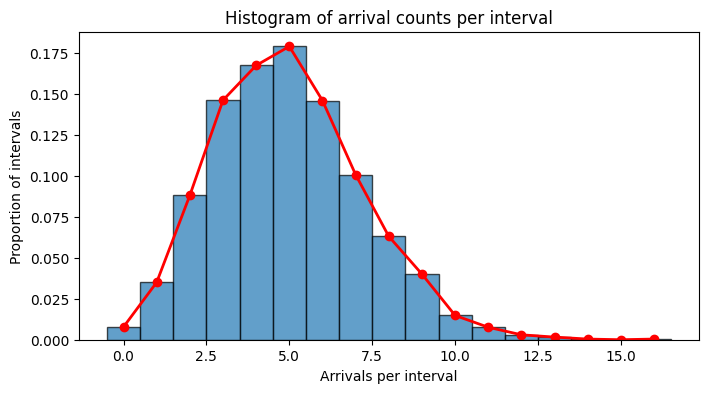

In [2]:
arrivals = np.loadtxt('data/session02_arrivals_per_interval.txt')

# Here we determine the bin ranges.
#
# Arrival counts per interval are discrete integers ($0, 1, 2, 3, \dots$). You cannot have $4.3$ 
# arrivals in an interval. In our dataset, arrivals.min() is 0 and arrivals.max() is 16. In this 
# case, np.arange(0, 17) generates integer boundaries: [0, 1, 2, ..., 15]. Adding 2 to the max, 
# gives [0, 1, 2, ..., 17]. Subtracting 0.5 shifts these edges to: [-0.5, 0.5, 1.5, 2.5, ..., 16.5].
#
# This apporach centers the integer values: The bin for the value 5 spans from 4.5 to 5.5. 
# This places the integer 5 exactly in the horizontal center of its histogram bar. 

bins = np.arange(arrivals.min(), arrivals.max() + 2) - 0.5

print(f"n = {len(arrivals)}")
print(f"mean = {arrivals.mean():.2f}, std = {arrivals.std():.2f}")
print(f"min = {arrivals.min():.2f}, max = {arrivals.max():.2f}")
print("==========================")
print("bins:", bins )

counts, bin_edges = np.histogram(arrivals, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 4))
plt.hist(arrivals, bins=bins, density=True, edgecolor='black', alpha=0.7)
plt.plot(bin_centers, counts, color='red', marker='o', linestyle='-', linewidth=2, label='Frequency Polygon')
plt.xlabel('Arrivals per interval')
plt.ylabel('Proportion of intervals')
plt.title('Histogram of arrival counts per interval')
#plt.legend()
plt.show()

---
### Checking the independence assumption

Before we go any further, it's worth pausing on an assumption we've been making silently: every goodness-of-fit test above, and every random-variate-generation step later in this notebook, assumes the observations are **independent and identically distributed (i.i.d.)**. We've checked the "identically distributed" part (via histograms and, next, via distribution fitting) -- but we haven't checked **independence** at all yet.

This matters because real operational data often *isn't* independent: a busy period tends to stay busy (a slow order at the register might mean the next customer's wait -- not order time itself, but related metrics -- is correlated with it), demand can trend across a shift, and arrival counts in adjacent intervals can cluster together (e.g. a rush persists across several consecutive 30-minute windows rather than resetting randomly each time). If the data are meaningfully autocorrelated, fitting a single "flat" distribution and sampling i.i.d. draws from it -- exactly what we do later in this notebook -- would understate real-world clustering, and a simulation built on it would understate how bad congestion gets during genuinely bad periods.

**A simple, standard check: a lag-1 scatter plot.** Plot each observation `X[i]` against the *next* observation `X[i+1]`. If the data are independent, this scatter should look like a shapeless cloud, with no visible pattern and a near-zero correlation. A visible trend (points clustering along a diagonal) suggests successive observations are related.


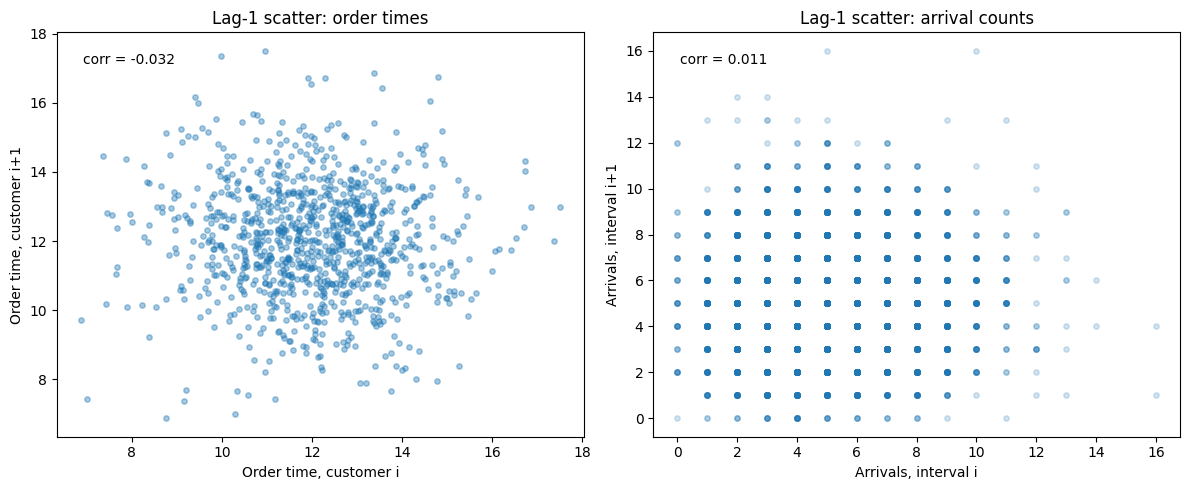

Lag-1 correlation, order times:    -0.0317
Lag-1 correlation, arrival counts: 0.0109


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Order times: lag-1 scatter
axes[0].scatter(order_times[:-1], order_times[1:], alpha=0.4, s=15)
axes[0].set_xlabel('Order time, customer i')
axes[0].set_ylabel('Order time, customer i+1')
axes[0].set_title('Lag-1 scatter: order times')
lag1_corr_orders = np.corrcoef(order_times[:-1], order_times[1:])[0, 1]
axes[0].text(0.05, 0.95, f"corr = {lag1_corr_orders:.3f}", transform=axes[0].transAxes, va='top')

# Arrival counts: lag-1 scatter
axes[1].scatter(arrivals[:-1], arrivals[1:], alpha=0.2, s=15)
axes[1].set_xlabel('Arrivals, interval i')
axes[1].set_ylabel('Arrivals, interval i+1')
axes[1].set_title('Lag-1 scatter: arrival counts')
lag1_corr_arrivals = np.corrcoef(arrivals[:-1], arrivals[1:])[0, 1]
axes[1].text(0.05, 0.95, f"corr = {lag1_corr_arrivals:.3f}", transform=axes[1].transAxes, va='top')

plt.tight_layout()
plt.show()

print(f"Lag-1 correlation, order times:    {lag1_corr_orders:.4f}")
print(f"Lag-1 correlation, arrival counts: {lag1_corr_arrivals:.4f}")


Both lag-1 correlations should come out close to zero here -- these two datasets were built to be independent, and the scatter plots should look like shapeless clouds rather than showing any diagonal trend. **In a real project, this won't always be true**, and you should not skip this check just because it "usually" comes out clean.

If you did see a meaningful lag-1 correlation in a real dataset, some options are:
- **Model the time-varying structure directly** rather than fitting one flat distribution (e.g. a non-homogeneous Poisson process with an arrival rate that changes by hour, rather than a single Poisson rate for the whole day)
- **Segment the data** into more homogeneous sub-periods (e.g. fit separate distributions for the morning rush vs. the afternoon lull) before fitting within each segment
- **Use the empirical distribution with resampling in blocks** (rather than i.i.d. resampling) to preserve short-run correlation structure, if the correlation itself matters for the questions your simulation needs to answer

A quick lag-1 scatter plot is a cheap habit to build **before** committing to any distribution fit -- it's the kind of check that takes thirty seconds and can save you from a simulation model built on a silently wrong assumption.


---
### Selecting a family of distributions

The purpose of preparing a histogram is to infer a known pdf or pmf. A family of distributions is selected on the basis of what might arise in the *context* being investigated along with the *shape* of the histogram. Thus, if order-time data have been collected, and the histogram has a
symmetric shape similar to the pdf in example above, the assumption of a normal distribution (or other bell-shaped distributions) would be warranted. Similarly, if measurements of the arrivals at the emergency department are being made, and the histogram appears to be similar to the one in the eample above, the assumption of a Poisson distribution would be warranted.


####  Common distributions

There are literally hundreds of probability distributions that have been created; many were created with
some specific physical process in mind. One aid to selecting distributions is to use the physical basis of the
distributions as a guide. Here are some examples (see Banks et al., 2005, for more examples):

| Distribution | Typical use | Why |
|---|---|---|
| **Exponential** | Time between arrivals (interarrival times) | Memoryless; arises naturally from Poisson arrival processes |
| **Poisson** | Number of arrivals in a fixed interval | Counts of independent events over a fixed time window |
| **Normal** | Service/processing times that cluster symmetrically around a mean | Central-limit-type behavior when many small factors add up |
| **Lognormal / Gamma** | Service or repair times that are positive and right-skewed | Many real processing times can't be negative and have a long right tail |
| **Uniform / Triangular** | Quick, low-data-availability estimates (min, max, or min-mode-max) | Useful when only rough judgment, not much data, is available |
| **Empirical distribution** | Anything that doesn't fit a clean theoretical shape well | Resamples directly from observed data — no assumption of shape, but also no ability to extrapolate beyond what was observed |

Picking the right entry in this table is a judgment call informed by data, which is exactly what the rest of this session helps you do systematically rather than by guesswork.


---
### Quantile-quantile plots

The construction of histograms and recognition of a distributional shape are necessary ingredients for selecting a family of distributions to represent a sample of data. However, a histogram is not as useful for evaluating the fit of the chosen distribution. When there is a small number of data points, say 30 or fewer, a histogram can be rather ragged. Further, our perception of the fit depends on the widths of the histogram intervals. But, even if the intervals are chosen well, grouping data into cells makes it difficult to compare a histogram to a continuous probability density function. A quantile-quantile (Q-Q) plot is a useful tool for evaluating distribution fit, one that does not suffer from these problems.


#### What is a Quantile-Quantile Plot?

Instead of grouping data into arbitrary bins, a Q-Q plot compares individual data points directly against what a theoretical candidate distribution predicts.Imagine taking your observed data points, sorting them from smallest to largest, and lining them up in order. Now, picture generating an ideal dataset of the exact same size from a candidate distribution (such as a Normal or Exponential distribution) and sorting those theoretical values from smallest to largest.

A Q-Q plot simply pairs these two sorted lists together and plots them as points on a two-dimensional graph:

- Horizontal Axis ($X$): Theoretical Quantiles (what the candidate distribution expects at each rank).
- Vertical Axis ($Y$): Sample Quantiles (what you actually observed at each rank).

If your sample data was generated by the candidate distribution, every observed rank value will closely match its corresponding theoretical rank value. As a result, the plotted points will form a clean, straight diagonal line ($y = x$). Deviations from this diagonal line immediately reveal where and how the assumed model fails to capture reality.

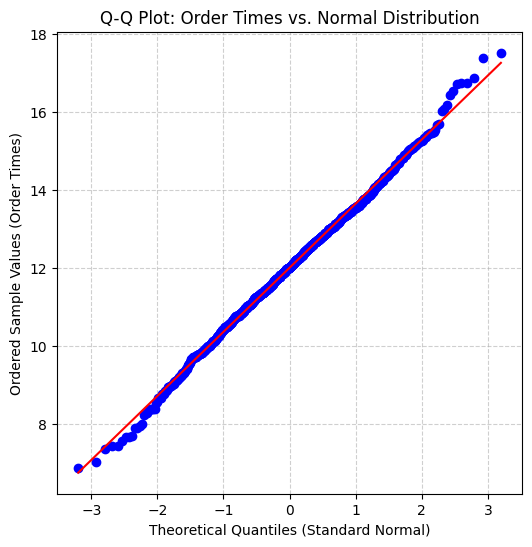

In [4]:
order_times = np.loadtxt('data/session02_order_times.txt')

plt.figure(figsize=(6, 6))

# For a given dataset and theoretical distribution, stats.probplot computes
# quantiles and plots against the theoretical distribution
stats.probplot(order_times, dist="norm", plot=plt)

plt.title("Q-Q Plot: Order Times vs. Normal Distribution")
plt.xlabel("Theoretical Quantiles (Standard Normal)")
plt.ylabel("Ordered Sample Values (Order Times)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

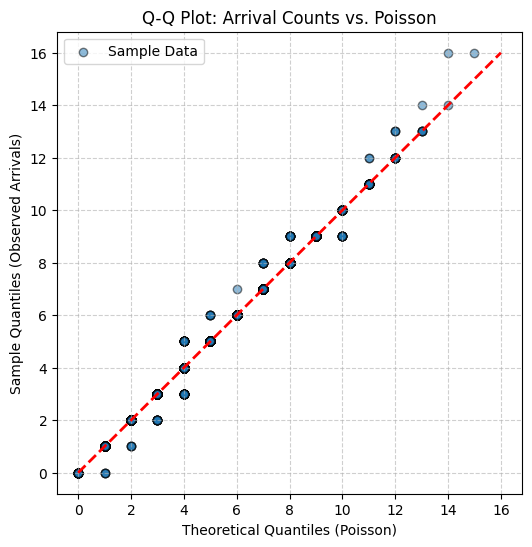

In [5]:
arrivals = np.loadtxt('data/session02_arrivals_per_interval.txt')

# 1. Estimate Poisson rate parameter (lambda = mean)
lambda_hat = arrivals.mean()

# 2. Sort the empirical sample data
n = len(arrivals)
sorted_arrivals = np.sort(arrivals)

# 3. Calculate empirical probabilities (plotting positions)
# Using (i - 0.5) / n to avoid probability = 1.0 at the endpoint
probabilities = (np.arange(1, n + 1) - 0.5) / n

# 4. Calculate theoretical Poisson quantiles
theoretical_quantiles = stats.poisson.ppf(probabilities, mu=lambda_hat)

# 5. Plot sample quantiles vs. theoretical quantiles
plt.figure(figsize=(6, 6))
plt.scatter(theoretical_quantiles, sorted_arrivals, alpha=0.5, edgecolors='k', label='Sample Data')

# Reference line y = x
max_val = max(theoretical_quantiles.max(), sorted_arrivals.max())
min_val = min(theoretical_quantiles.min(), sorted_arrivals.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.title("Q-Q Plot: Arrival Counts vs. Poisson")
plt.xlabel("Theoretical Quantiles (Poisson)")
plt.ylabel("Sample Quantiles (Observed Arrivals)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

---
### Fitting a probability distribution

Fitting distributions to data is a very common task in statistics and consists in choosing a probability distribution modelling the random variable, as well as finding parameter estimates for that distribution. This requires judgment and expertise and generally needs an *iterative* process of distribution choice, parameter estimation, and quality of fit assessment. Note that histograms and Q-Q plots can possibly inform this judgemntal process.

The process start by by asking: *Is the underlying physical phenomenon continuous or discrete?*

Take customer order processing times: while recorded in whole seconds, the underlying physical process is continuous. Modeling it with a continuous distribution reflects physical reality and allows your simulation model to sample realistic non-integer durations (like 12.43 minutes). Conversely, modeling machine breakdown counts per shift requires a discrete distribution, as half a breakdown is physically meaningless.


#### Fitting continuous distributions

Continuous distributions model quantities that can take any real value along a continuum ($X \in \mathbb{R}$), such as task completion times, lead times, or material weights.

The fitting workflow follows three primary phases:

1. **Exploratory Screening:** Examining empirical properties, such as skewness, kurtosis, and tail behavior, to narrow down candidate families (e.g., Normal, Log-Normal, Gamma, or Weibull).
2. **Parameter Estimation:** Using Maximum Likelihood Estimation (MLE) or matching moments to estimate the specific parameters (such as mean, scale, or shape) for each candidate distribution. This is done by exisitng packages.
3. **Goodness-of-Fit Assessment:** Evaluating candidates visually via density overlays, Quantile-Quantile (Q-Q) plots, and Cumulative Distribution Function (CDF) comparisons, supplemented by continuous statistical tests like the Kolmogorov-Smirnov or Anderson-Darling tests.

**Example**: Once we decide that a continuous model like the normal distribution is a good candidate for our order times data, our next task is parameter estimation.

Every probability distribution is defined by parameters. For a Normal distribution, these parameters are:
- $\mu$ (location / mean): Centers the distribution.
- $\sigma$ (scale / standard deviation): Controls the spread or width of the distribution.

[SciPy package](https://docs.scipy.org/doc/scipy/index.html) makes estimating these parameters straightforward through the `.fit()` method available on distribution objects in `scipy.stats`. Click [here](https://docs.scipy.org/doc/scipy/reference/stats.html)  to see list of continuous and discrete distributions supported by `scipy.stats`.

In [6]:
mu_hat, sigma_hat = stats.norm.fit(order_times)

print(f"The fitted mean and standard deviations are {mu_hat:.2f} and {sigma_hat:.2f}, respectively.")

The fitted mean and standard deviations are 12.00 and 1.64, respectively.


Visually the fit looks like this:

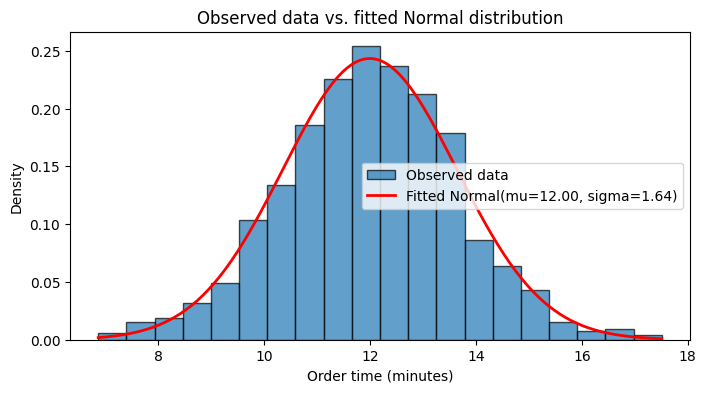

In [7]:
x = np.linspace(order_times.min(), order_times.max(), 200)
fitted_pdf = stats.norm.pdf(x, mu_hat, sigma_hat)

plt.figure(figsize=(8, 4))
plt.hist(order_times, bins=20, density=True, edgecolor='black', alpha=0.7, label='Observed data')
plt.plot(x, fitted_pdf, 'r-', linewidth=2, label=f'Fitted Normal(mu={mu_hat:.2f}, sigma={sigma_hat:.2f})')
plt.xlabel('Order time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.title('Observed data vs. fitted Normal distribution')
plt.show()

---
### Goodness-of-fit

Visually the fit looks reasonable, but "looks reasonable" is not a statistical test. Goodness-of-fit tests provide helpful guidance for evaluating the suitability of a potential input model. However, there is no single correct distribution in a real application, so we should not be a slave to the verdict of such a test. It is especially important to understand the effect of sample size. If very little data are available, then a goodness-of-fit test is unlikely to reject any candidate distribution; but if a lot of data are available, then a goodness-of-fit test will likely reject all candidate distributions. Therefore, failing to reject a candidate distribution should be taken as one piece of evidence in favor of that choice, and rejecting an input model as only one piece of evidence against the choice.

We can formally test the goodness-of-fit using the **Kolmogorov–Smirnov (KS) test**, which compares the empirical distribution of the data to the fitted theoretical CDF.

**Hypotheses:**
- H0:  The data follow the specified theoretical distribution.
- H1:  The data do not follow the specified distribution.

A small p-value (conventionally < 0.05) would lead us to reject H0.

Let's try this on our example:


In [8]:
# Fit parameters (MLE)
params = stats.norm.fit(order_times)

# Build a frozen distribution with those params, then pass its
# .cdf method directly to kstest — avoids the args= dispatch bug
frozen_dist =stats.norm(*params).cdf

ks_stat, p_value = stats.kstest(order_times, frozen_dist)

print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")


# ad_stat, p_value = stats.anderson(order_times, dist='norm', method='interpolate')
#
# print(f"AD statistic: {ad_stat:.4f}")
# print(f"p-value: {p_value:.4f}")


KS statistic: 0.0202
p-value: 0.8012


##### Interpreting the KS test results

- *KS Statistic*: The KS statistic is the maximum distance between the empirical CDF of the data and the fitted normal distribution's CDF, bounded between 0 (perfect match) and 1 (total mismatch). A value of *0.0202* is very small; the two curves never diverge by more than ~2 percentage points in cumulative probability, indicating a tight fit.
- *p-value*:
The p-value is the probability of observing a KS statistic this large (or larger) **if the data truly came from a normal distribution** with the fitted parameters. A p-value of *0.8012* means a discrepancy this size would occur ~80% of the time by chance alone under the null hypothesis.
- *Conclusion*:
At a 5% significance level, we *fail to reject the null hypothesis* that the data is normally distributed. The small KS statistic combined with the high p-value indicates the data is not inconsistent with a normal distribution.

<u>Important interpretation note</u>: "fail to reject the null hypothesis" does **not** mean "the data definitely *is* Normal" — it means the data is *not inconsistent* with a Normal assumption at this sample size. With very large samples, even tiny, practically irrelevant deviations can produce a significant test statistic; with very small samples, almost any distribution will "pass." Goodness-of-fit tests are evidence to weigh alongside the visual fit and domain knowledge — not a mechanical yes/no oracle.


<!--
*Caveats*:
- **Parameters were estimated from the same data being tested.** Standard `kstest` assumes distribution parameters are known in advance, not fit from the sample (this is the Lilliefors scenario). This makes the reported p-value **conservative** — the true p-value under proper correction would likely be even more favorable. For a statistically rigorous version, consider `statsmodels.stats.diagnostic.lilliefors`.
- **A high p-value indicates consistency with normality, not proof of it.** The test may have limited power to detect subtle deviations (e.g., mild skewness, heavy tails), especially with smaller sample sizes.
- **Recommended follow-up:** A Q-Q plot (`stats.probplot(data, dist='norm', plot=plt)`) provides a visual complement, showing *where* (if anywhere) deviations from normality occur.
-->

We can repeat the test for a number of candidate distributions and compare them:

In [9]:
import scipy.stats as stats

data = order_times

candidate_distributions = [
    stats.norm,
    stats.lognorm,
    stats.gamma,
    stats.weibull_min,
    stats.expon,
    stats.uniform
]

best_dist = None
best_params = None
best_ks_stat = float('inf')

# create an empty list to save results
results = []

for dist in candidate_distributions:

    # Fit parameters (MLE)
    params = dist.fit(data)

    # Build a frozen distribution with those params, then pass its
    # .cdf method directly to kstest — avoids the args= dispatch bug
    frozen = dist(*params).cdf

    # Perform the KS test and colelct the ks statisitic and p-value
    ks_stat, p_value = stats.kstest(data, frozen)

    # Append the result to the result list
    results.append((dist.name, ks_stat, p_value, params))

    # Check if the test has resulted in the smallest ks statistic
    if ks_stat < best_ks_stat:
        best_ks_stat = ks_stat
        best_dist = dist
        best_params = params

# Sort the resutls accoding to the ks statistic
results.sort(key=lambda x: x[1])

# pring the goodness-of-fit results
print("--- Goodness-of-Fit Ranking ---")
for name, ks_stat, p_val, params in results:
    print(f"{name:12s} | KS Stat: {ks_stat:.4f} | p-value: {p_val:.4f}")

best_params_float = tuple(float(p) for p in best_params)

print("\nBest Fitting Distribution:", best_dist.name)
print("Fitted Parameters:", best_params_float)

--- Goodness-of-Fit Ranking ---
gamma        | KS Stat: 0.0201 | p-value: 0.8068
lognorm      | KS Stat: 0.0202 | p-value: 0.8012
norm         | KS Stat: 0.0202 | p-value: 0.8012
weibull_min  | KS Stat: 0.0275 | p-value: 0.4282
uniform      | KS Stat: 0.2322 | p-value: 0.0000
expon        | KS Stat: 0.3522 | p-value: 0.0000

Best Fitting Distribution: gamma
Fitted Parameters: (6518.564603805007, -120.45580176790423, 0.020319202221040306)


Because the p-value is a strictly decreasing function of the KS statistic for a fixed sample size $n$, the distribution with the smallest KS statistic will always have the largest (best) p-value. In the example above, among the distributions for which the test is performed, a gamma istributions with parameters (shape, location, scale)=(6518.56, -120.46, 0.02). We can observe that, even though a normal distribution seemed to be a good fit based on a visual inspection, gamma and lognormal distributions happen to be better fits for the order times dataset.

**A caveat worth internalizing here:** look closely at the fitted Gamma parameters above -- a shape parameter around 6,500 is not a meaningful modeling result. As a Gamma distribution's shape parameter grows very large, the distribution numerically converges to a Normal distribution. What's actually happened is that `gamma.fit()`, with its location parameter free to float, found a heavily-shifted, huge-shape Gamma that reconstructs the Normal fit almost exactly -- not a genuinely different or better-motivated model of the underlying process.

This is a general trap worth watching for whenever you rank several fitted distributions purely by a goodness-of-fit statistic: **the "winner" isn't automatically the best modeling choice.** Two checks worth making before trusting a ranking like this one:

- **Sanity-check the fitted parameters themselves.** A shape or scale parameter that's absurdly large, tiny, or has no natural interpretation for the quantity you're modeling (order times can't really have a Gamma "location" of -120) is a signal the optimizer found a numerically convenient fit, not a physically meaningful one.
- **Prefer simpler, more interpretable distributions when the fit is close.** Here, Normal, Lognormal, and Gamma all have KS statistics within 0.0001 of each other (0.0202 vs 0.0202 vs 0.0201) -- statistically indistinguishable given this sample. In that situation, the Normal distribution (two interpretable parameters, no floating location) is the more defensible choice for a simulation input model than a Gamma fit that only "wins" by exploiting a large shape parameter.

The general lesson: **goodness-of-fit statistics rank fits, they don't validate models.** Interpretability and a sensible parameter range are just as much a part of "selecting and justifying" (Step 6 of the workflow above) as the numerical fit itself.


#### Fitting discrete distributions

We may also need to fit discrete distributions such as:

- The Poisson distribution which is a discrete probability distribution that expresses the probability of a given number of events occurring in a fixed interval of time and/or space if these events occur with a known average rate and independently of the time since the last event. The Poisson distribution can be applied to systems with a large number of possible events, each of which is rare. How many such events will occur during a fixed time interval? Under the right circumstances, this is a random number following a Poisson distribution.

- The binomial distribution which is a probability distribution that is used to model the number of successes in a sequence of $n$ independent experiments with probability $p$ for success. The Bernoulli distribution is a special case of the Binomial distribution where $n=1$ (one experiment).

- The negative binomial distribution which is a discrete probability distribution that models the number of failures in a sequence of independent and identically distributed Bernoulli trials before a specified number of successes occurs.

- The geometric distribution which is a special case of the negative binomial distribution where the specified number of successes are one.


The fitting workflow adapts specifically for integer-valued random variables:

1. **Dispersion Diagnostics:** Comparing sample variance to the sample mean. For a standard Poisson process, variance equals the mean. If sample variance significantly exceeds the mean (overdispersion), candidate families shift toward Negative Binomial or Geometric distributions.
2. **Parameter Estimation:** Fitting parameters for candidate discrete distributions (such as Poisson, Binomial, or Negative Binomial) using discrete maximum likelihood methods. For the afore-mentioend distributions the paramters can easily be estimated as follows:

| Distribution (parameters)               | Application | Estimation                                                                                                           |
|-----------------------------------------|--------------------------------------------|----------------------------------------------------------------------------------------------------------------------|
| Poisson Distribution ($\lambda$)        | Time between arrivals (interarrival times) | Memoryless; arises naturally from Poisson arrival processes $$\lambda = \bar{x} $$                                   |
| Binomial Distribution ($n, p$)          | Count of success events across $n$ fixed trials. | Given a known trial count $n$, set success probability $$\hat{p} = \bar{x} / n$$                                     |
| Negative Binomial Distribution ($r, p$) | Overdispersed count data where sample variance exceeds the sample mean ($s^2 > \bar{x}$) | Solve using the Method of Moments:$$\hat{p} = \frac{\bar{x}}{s^2}, \quad \hat{r} = \frac{\bar{x}^2}{s^2 - \bar{x}}$$ |
| Geometric Distribution ($p$)            | Number of trials until the first success. | Set parameter $$\hat{p} = 1 / \bar{x}$$ (where $\bar{x}$ is the sample mean).                                        |


3. **Goodness-of-Fit Assessment:** Comparing observed sample frequencies directly against theoretical probability mass functions, using discrete Q-Q plots and Chi-Square goodness-of-fit tests designed specifically for discrete data.

We can formally test the goodness-of-fit for discrete data using the Chi-Square ($\chi^2$) test, which compares the observed outcome counts to the expected counts under the fitted theoretical PMF.

**Hypotheses:**
- $H_0$: The discrete data follow the specified theoretical distribution.
- $H_1$: The discrete data do not follow the specified distribution.

A small $p$-value (conventionally $< 0.05$) leads us to reject $H_0$. Key Difference from KS test is that the Chi-Square test evaluates grouped frequency counts rather than cumulative distribution functions, requiring outcomes to be grouped into bins where expected counts in each bin is greater than 5..



**Example**: Let's fit the Poisson distribution (its single parameter, lambda, is estimated by MLE as simply the sample mean) and test fit with a chi-square goodness-of-fit test.

In `scipy.stats`, discrete distributions (like `poisson`, `binom`, `geom`) do not have a `.fit()` method. The `.fit()` method is only implemented for continuous distributions (`scipy.stats.rv_continuous`). Calling it on a discrete distribution will raise an `AttributeError`.


In [10]:
lam_hat = arrivals.mean()
print(f"Fitted Poisson: lambda = {lam_hat:.3f}")

# Build observed frequency table over the observed range of counts
values, observed_counts = np.unique(arrivals, return_counts=True)

#print(values)
#print(observed_counts)

# Expected counts under the fitted Poisson
# (rescaled so expected and observed totals match exactly -  we're only
# summing probability mass over the observed range of values, not the
# Poisson's full infinite support, so a small renormalization is needed)
expected_props = stats.poisson.pmf(values, lam_hat)
expected_counts = expected_props * len(arrivals)
expected_counts *= observed_counts.sum() / expected_counts.sum()

# Compare observed vs expected visually
comparison = pd.DataFrame({
    'arrivals': values,
    'observed': observed_counts,
    'expected (Poisson fit)': expected_counts.round(1)
})
print(comparison)

chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(f"\nChi-square statistic: {chi2_stat:.3f}")
print(f"p-value:  {p_value:.4f}")

Fitted Poisson: lambda = 4.955
    arrivals  observed  expected (Poisson fit)
0        0.0        39                    35.2
1        1.0       175                   174.6
2        2.0       440                   432.6
3        3.0       730                   714.6
4        4.0       836                   885.2
5        5.0       894                   877.3
6        6.0       729                   724.5
7        7.0       503                   512.9
8        8.0       315                   317.7
9        9.0       200                   174.9
10      10.0        74                    86.7
11      11.0        38                    39.0
12      12.0        15                    16.1
13      13.0         8                     6.1
14      14.0         2                     2.2
15      16.0         2                     0.2

Chi-square statistic: 24.486
p-value:  0.0573


##### Interpreting the Chi-Square Test Results

- *Chi-Square Statistic*: The chi-square statistic measures the total weighted discrepancy between observed and expected counts across all bins<!--, summing $(O-E)^2/E$ for each category-->. Larger values indicate the observed counts deviate more from what a Poisson($\lambda$) distribution would predict. A value of *24.486* reflects the accumulated mismatch across all 16 bins (arrivals 0 through 16) — some bins (e.g., 9 arrivals: observed 200 vs. expected 174.9; 16 arrivals: observed 2 vs. expected 0.2) contribute noticeably more to this total than others.
- *p-value*:
The p-value is the probability of observing a chi-square statistic this large (or larger) **if the data truly came from a Poisson distribution** with $\lambda = 4.955$. A p-value of *0.0573* means a discrepancy this size would occur ~5.7% of the time by chance alone under the null hypothesis.
- *Conclusion*:
At a 5% significance level, we *fail to reject the null hypothesis* that the data follows a Poisson($\lambda=4.955$) distribution — but only just. The p-value sits right at the conventional threshold, so this is a **borderline result**, not a clean pass.

<u>Important interpretation note</u>: "fail to reject the null hypothesis" does **not** mean "the data definitely *is* Poisson"; it means the data is *not inconsistent* with a Poisson assumption at this sample size, and here the margin is thin (0.0573 vs. 0.05). A p-value this close to the cutoff is sensitive to bin choice (e.g., how tail categories are grouped) and to sample size — with a slightly larger sample or different binning, the same underlying discrepancy could easily cross into "reject" territory. Worth checking the residuals bin-by-bin: the largest deviations here (arrivals = 9, and the tail at 16) suggest the right tail may be slightly heavier than a Poisson would predict, which could indicate mild overdispersion — worth cross-checking against a Negative Binomial fit if this matters for your application. As before, treat this as evidence to weigh alongside visual fit (e.g., a bar plot of observed vs. expected) and domain knowledge, not a mechanical yes/no oracle.

### Discussion: interpreting the chi-square result

- If the p-value is small, what would that tell you about the Poisson assumption — and what real-world features of arrivals (e.g. batch arrivals, time-varying arrival rates) might explain a poor fit?
- The chi-square test can be sensitive to how counts are grouped/binned, especially when some categories have very few observations. Does that concern apply here, given how many distinct values `arrivals` takes?


---
### Generating random variates from a fitted distribution

Fitting a distribution is only useful if we can then **sample** from it to drive a simulation. `scipy.stats` makes this direct once you have fitted parameters.


In [11]:
rng = np.random.default_rng(seed=42)

# Draw 10 simulated order times from the fitted Normal
simulated_order_times = stats.norm.rvs(loc=mu_hat, scale=sigma_hat, size=10, random_state=rng)
print("Simulated order times:", np.round(simulated_order_times, 2))

# Draw 10 simulated interval arrival counts from the fitted Poisson
simulated_arrivals = stats.poisson.rvs(mu=lam_hat, size=10, random_state=rng)
print("Simulated arrival counts:", simulated_arrivals)


Simulated order times: [12.5  10.29 13.23 13.54  8.8   9.86 12.21 11.48 11.97 10.6 ]
Simulated arrival counts: [7 9 6 3 8 3 7 8 5 6]


Notice the Normal fit can, in principle, generate a *negative* order time (unlikely given these parameters, but not impossible) — a reminder that a fitted distribution is a convenient approximation, not a perfect description of reality. This is exactly the kind of judgment call worth documenting when you justify an input choice: does the theoretical support of the distribution make physical sense for this quantity?


---
### Generating random variates from an *empirical* distribution

Recall the "Empirical distribution" row from the common-distributions table earlier: when no theoretical family fits well -- or when you'd simply rather not impose a distributional assumption at all -- you can sample directly from the data itself, with no fitted parameters involved. This section shows how, for both a **discrete** dataset (arrival counts) and a **continuous** dataset (order times), since the two cases need genuinely different techniques.


#### Discrete case: resampling with replacement

For discrete data like `arrivals`, the empirical distribution is simple: treat every observed value as equally likely to be redrawn, in proportion to how often it actually occurred. This is just **sampling with replacement** from the raw data -- the technique underlying the statistical bootstrap.


Simulated arrival counts (empirical): [ 4  8  2  8  6  5  6  8 14  7]


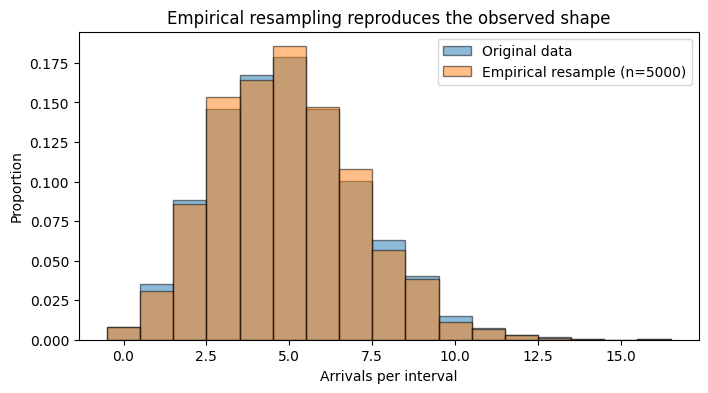

In [12]:
rng_emp = np.random.default_rng(seed=7)

# Draw 10 simulated arrival counts directly from the observed data (bootstrap resampling)
simulated_arrivals_empirical = rng_emp.choice(arrivals, size=10, replace=True)
print("Simulated arrival counts (empirical):", simulated_arrivals_empirical.astype(int))

# At scale, this reproduces the observed distribution's shape exactly (by construction)
large_sample_empirical = rng_emp.choice(arrivals, size=5000, replace=True)

plt.figure(figsize=(8, 4))
bins = np.arange(arrivals.min(), arrivals.max() + 2) - 0.5
plt.hist(arrivals, bins=bins, density=True, alpha=0.5, edgecolor='black', label='Original data')
plt.hist(large_sample_empirical, bins=bins, density=True, alpha=0.5, edgecolor='black', label='Empirical resample (n=5000)')
plt.xlabel('Arrivals per interval')
plt.ylabel('Proportion')
plt.title('Empirical resampling reproduces the observed shape')
plt.legend()
plt.show()


#### Continuous case: linear interpolation between order statistics

Naively bootstrap-resampling a *continuous* dataset (`order_times`) the same way would only ever reproduce values that were literally observed -- never anything in between, and never anything smoother than the raw sample. The standard fix is to build a **piecewise-linear empirical CDF**: sort the data, connect the sorted points with straight line segments to form an approximate CDF, and then generate variates via inverse-CDF sampling against that piecewise-linear curve. This lets the empirical distribution produce values *between* observed data points, while still never extrapolating beyond the observed range.

Conveniently, this is exactly what `np.interp` does if we hand it the sorted data as the interpolation targets and evenly-spaced cumulative probabilities as the interpolation points.


Simulated order times (empirical): [13.55 14.62 10.55  7.93 14.91 13.64 12.47 13.41 12.42 14.08]


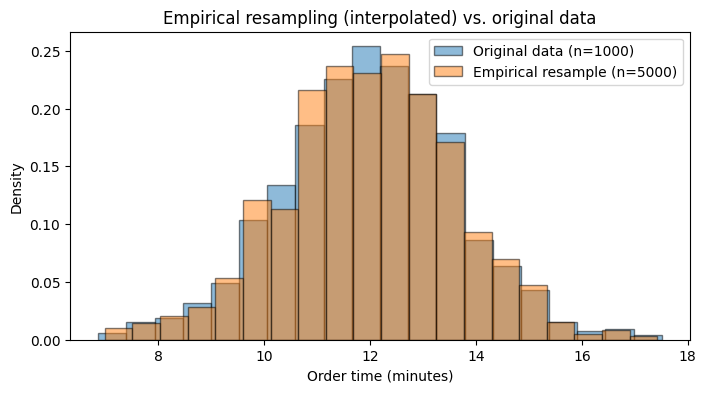


Original data range:            [6.87, 17.51]
Empirical resample range (n=5000): [6.99, 17.43]


In [13]:
def sample_empirical_continuous(data, size, rng):
    sorted_data = np.sort(data)
    n = len(sorted_data)
    cdf_points = np.arange(n) / (n - 1)     # 0, 1/(n-1), 2/(n-1), ..., 1
    u = rng.uniform(0, 1, size=size)
    return np.interp(u, cdf_points, sorted_data)

simulated_order_times_empirical = sample_empirical_continuous(order_times, size=10, rng=rng_emp)
print("Simulated order times (empirical):", np.round(simulated_order_times_empirical, 2))

large_sample_empirical_continuous = sample_empirical_continuous(order_times, size=5000, rng=rng_emp)

plt.figure(figsize=(8, 4))
plt.hist(order_times, bins=20, density=True, alpha=0.5, edgecolor='black', label='Original data (n=1000)')
plt.hist(large_sample_empirical_continuous, bins=20, density=True, alpha=0.5, edgecolor='black',
         label='Empirical resample (n=5000)')
plt.xlabel('Order time (minutes)')
plt.ylabel('Density')
plt.title('Empirical resampling (interpolated) vs. original data')
plt.legend()
plt.show()

print(f"\nOriginal data range:            [{order_times.min():.2f}, {order_times.max():.2f}]")
print(f"Empirical resample range (n=5000): [{large_sample_empirical_continuous.min():.2f}, {large_sample_empirical_continuous.max():.2f}]")


### Empirical vs. fitted (parametric) distributions: the trade-off

Notice the empirical resample's range in the output above -- it can never exceed the range of the original 1,000 observations, no matter how many variates you draw. This is the central trade-off of the empirical approach:

| | **Parametric (fitted)** | **Empirical** |
|---|---|---|
| **Can generate values beyond the observed range?** | Yes (e.g. a fitted Normal can, in principle, produce a value outside the sample's min/max) | No -- bounded by the observed data's range, always |
| **Smoothness** | Smooth, governed by the distribution's shape | Only as smooth as the interpolation; can inherit "bumps" that are really just sampling noise in the original data |
| **Requires choosing/justifying a distribution family?** | Yes | No -- no distributional assumption at all |
| **Good choice when...** | You have reason to believe a specific family is a genuine, physically-motivated model (as in Section 2's table), and/or you need to extrapolate somewhat beyond the observed data | You have enough data to trust its shape directly, no theoretical family fits well, or you specifically want to avoid imposing an assumption you can't justify |

Neither is universally "more correct" -- it's a modeling choice, and part of what Step 6 of the input-modeling workflow ("selecting and justifying") asks you to actually think through, not default on.


## Exercise (guided): mini input-analysis lab

You're given a new (synthetic) dataset representing **service times at a second workstation**, generated below. Work through the full input-modeling workflow from Section 3:

1. Visualize the data (histogram, summary statistics)
2. Propose a candidate distribution based on the shape (hint: service times are positive and often right-skewed — consider `stats.gamma` or `stats.lognorm` in addition to Normal)
3. Fit your candidate via MLE (`stats.<dist>.fit(data)`)
4. Test goodness-of-fit with the KS test
5. State, in a sentence, whether you'd adopt this distribution for a simulation model and why


In [14]:
# Synthetic "workstation 2" service time data — do not change this cell
_rng = np.random.default_rng(7)
workstation2_times = _rng.gamma(shape=3.0, scale=2.0, size=400)

# EXERCISE
# TODO: 1. Plot a histogram of workstation2_times and print summary statistics

# TODO: 2-3. Fit a candidate distribution (try more than one if you like)

# TODO: 4. Run a KS goodness-of-fit test against your fitted distribution

# TODO: 5. Print one sentence stating your conclusion


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
plt.figure(figsize=(8, 4))
plt.hist(workstation2_times, bins=30, density=True, edgecolor='black', alpha=0.7)
plt.xlabel('Service time')
plt.ylabel('Density')
plt.title('Workstation 2 service times')
plt.show()

print(f"mean = {workstation2_times.mean():.2f}, std = {workstation2_times.std():.2f}")
print(f"min = {workstation2_times.min():.2f}, max = {workstation2_times.max():.2f}")

# Candidate: Gamma
shape_hat, loc_hat, scale_hat = stats.gamma.fit(workstation2_times, floc=0)
print(f"Fitted Gamma: shape = {shape_hat:.3f}, scale = {scale_hat:.3f}")

ks_stat, p_value = stats.kstest(workstation2_times, 'gamma', args=(shape_hat, loc_hat, scale_hat))
print(f"KS statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: reject the Gamma assumption at the 5% level.")
else:
    print("Conclusion: the Gamma distribution is a statistically plausible fit and is a "
          "reasonable choice given the positive, right-skewed shape of the data.")
```
</details>


### Discussion questions

1. Why does it make sense to fix the location parameter to 0 (`floc=0`) when fitting a Gamma distribution to service times specifically?
2. If your forecast from Advanced Data Analysis gave you a point forecast *and* a historical distribution of forecast errors, how might you combine the two into a distribution suitable as a simulation input (rather than just simulating with the point forecast as a constant)?
3. Suppose two candidate distributions both pass their goodness-of-fit test. What other considerations (beyond the p-value) might help you choose between them for a simulation study?


## Wrap-up

Today we:

- Established why input modeling matters: it's where real-world data enters a simulation, and simulation conclusions are only as credible as this step
- Walked through the full input-modeling workflow: visualize → hypothesize → fit → test → justify
- Fitted and tested a continuous distribution (Normal, via KS test) to real order-time data
- Fitted and tested a discrete distribution (Poisson, via chi-square test) to real arrival-count data
- Generated random variates from fitted (parametric) distributions — the building block for every Monte Carlo and DES model from here on
- Generated random variates from empirical distributions instead, for both discrete and continuous data, and weighed the trade-offs against the parametric approach
- Practiced the full workflow independently on a new dataset

**Next session:** Fundamentals of Monte Carlo Simulation — we'll use exactly this kind of fitted input distribution to build a full Monte Carlo model (the Newsvendor problem) and compute point and interval estimates of a decision's performance under uncertainty.
